# AN2DL - Homework 1

## 1 - Libraries and Dataset Import

In [ ]:
'''from google.colab import drive

drive.mount('/gdrive')
%cd /gdrive/My Drive/[2024-2025] AN2DL/Homework 1'''

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/My Drive/[2024-2025] AN2DL/Homework 1


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras as tfk

np.random.seed(42)
tf.random.set_seed(42);

In [28]:
data = np.load('training_set.npz')

X = data['images']
y = data['labels']
print(X.shape, y.shape)

(13759, 96, 96, 3) (13759, 1)


## 2 - Check for missing, duplicate values and class distribution

In [21]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [ ]:
# Duplicates count and removal
import hashlib

image_hashes = [hashlib.md5(img.tobytes()).hexdigest() for img in X]
df = pd.DataFrame({'image_hash': image_hashes, 'label': y.flatten()})
unique_df = df.drop_duplicates(subset='image_hash').reset_index(drop=True)

# Manual duplicates check
'''
# Count duplicates by grouping by label and hash
duplicate_counts = (
    unique_df[unique_df.duplicated(subset=['image_hash'], keep=False)]
    .groupby('label')
    .size()
)

# Display the counts
print("Duplicate Counts per Label:")
print(duplicate_counts)
'''

X_unique  = X[unique_df.index]
y_unique = y[unique_df.index]
print(f'Labels reduced from {len(y)} to {len(y_unique)}')
# (should output a reduction from 13759 to 11953)

Labels reduced from 13759 to 11953


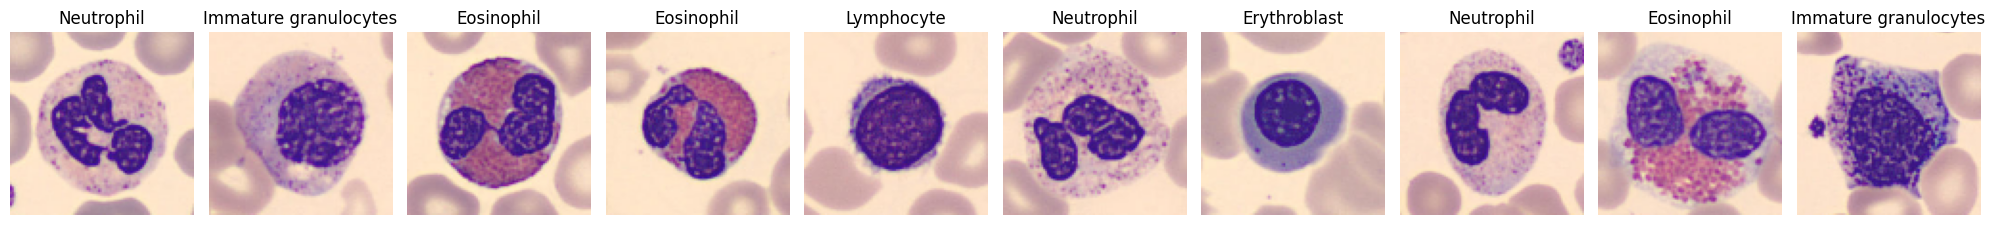

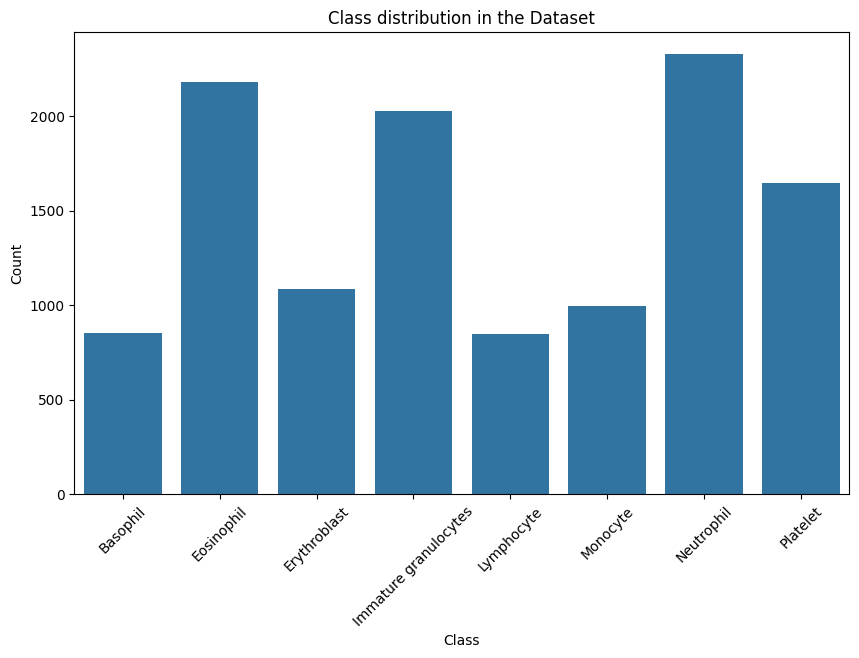

In [30]:
X = X_unique
y = y_unique

# Define a mapping of labels to their corresponding digit names
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Save unique labels
unique_labels = list(labels.values())

# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[y[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
plt.show()

labels_list, counts = np.unique(y.flatten(), return_counts=True)
classes = [labels[label] for label in labels_list]
df = pd.DataFrame({'Class': classes, 'Count': counts})

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=counts)
plt.title('Class distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Adjust rotation for readability if needed
plt.show()

## 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [31]:
# Split data into training, test and validation sets, maintaining class distribution
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val, test_size = 0.1, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

Training Data Shape: (8605, 96, 96, 3)
Training Label Shape: (8605, 1)
Test Data Shape: (2391, 96, 96, 3)
Test Label Shape: (2391, 1)
Validation Data Shape: (957, 96, 96, 3)
Validation Label Shape: (957, 1)


## 4 - Image Augmentation

**Note for Kalisto and Matteo** : This is not how we did it in the ewercise sessions but I think it's an easier way. All you have to do then is train your model with : model.fit(augmentation.flow(X_train, y_train),...) and it performs the augmentation on the go and uses less memory. If you think we should rather perform the augmentation before training we could also try it.

In [32]:
# Choose augmentation options
augmentation = tfk.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit the generator to training data
augmentation.fit(X_train)
